# Algorithm Evaluation
Considering dataset TH50 for default K values (SELECT k=5, FROM/WHERE k=3)

CPU times: user 2.47 s, sys: 315 ms, total: 2.78 s
Wall time: 13.9 s


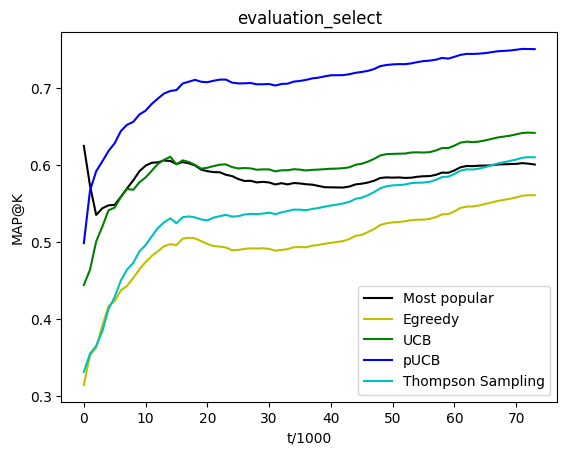

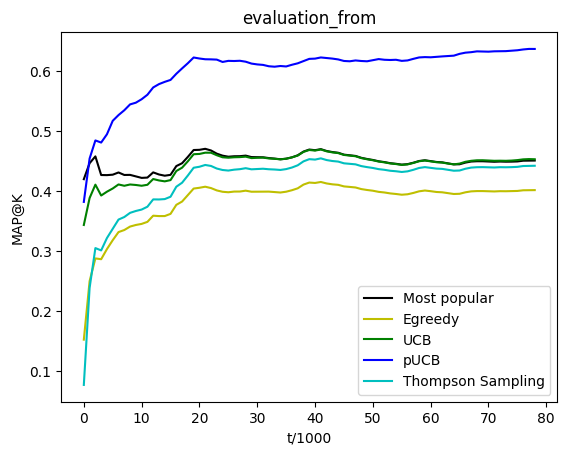

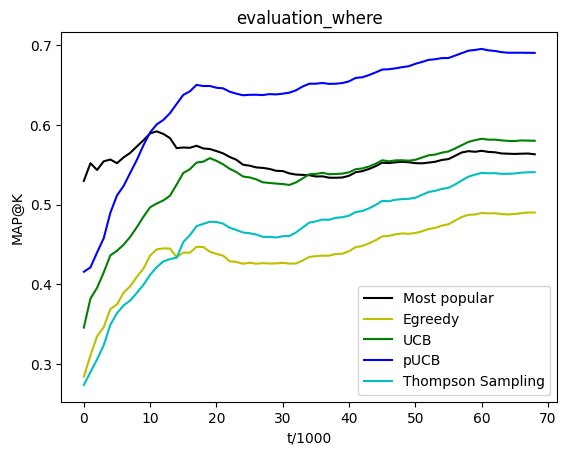

In [2]:
%%time
from sdss_eval.evaluator import run_n_tests, create_tests
from sdss_eval.sqlparser import schema



clauses_to_test = [0, 1, 2]
k_to_test = [[5],[3],[3]]
thresholds_to_test = [50]

test_names = ["evaluation_select", "evaluation_from", "evaluation_where"]

db = schema()
results = []
for clause in clauses_to_test:
    tests = []
    for k in k_to_test[clause]:
        for th in thresholds_to_test:
            tests = create_tests(algorithms=["egreedy","thompson", "ucb", "pucb", "popular"], clause=clause, top_k = k , db = db , th = th )
    
    results.append(run_n_tests(tests,test_names[clause]).results)

## SELECT Clause

In [3]:
results[0]

,Test,MAP@K,Execution Time
3,pUCB,0.75,0.04
2,UCB,0.64,0.03
4,Thompson Sampling,0.61,0.06
0,Most popular,0.60,0.02
1,Egreedy,0.56,0.03


## FROM Clause

In [4]:
results[1]

,Test,MAP@K,Execution Time
3,pUCB,0.64,0.02
0,Most popular,0.45,0.01
2,UCB,0.45,0.01
4,Thompson Sampling,0.44,0.04
1,Egreedy,0.40,0.01


### WHERE Clause

In [5]:
results[2]

,Test,MAP@K,Execution Time
3,pUCB,0.69,0.04
2,UCB,0.58,0.03
0,Most popular,0.56,0.02
4,Thompson Sampling,0.54,0.06
1,Egreedy,0.49,0.02
